  PREVIEW DATASET
   age education_level  study_hours_per_day uses_ai ai_tools_used  \
0   19         college                  1.4      No           NaN   
1   15          school                  3.9     Yes       Copilot   
2   15          school                  1.9     Yes       Copilot   
3   15          school                  2.8      No           NaN   
4   19         college                  2.7      No           NaN   

  purpose_of_ai  grades_before_ai  grades_after_ai  daily_screen_time_hours  
0           NaN                62               62                        3  
1      Research                56               61                        2  
2      Homework                75               88                        5  
3           NaN                55               55                        3  
4           NaN                59               59                        3  

Shape    : 100 baris x 9 kolom
Kolom    : ['age', 'education_level', 'study_hours_per_day', 'uses_

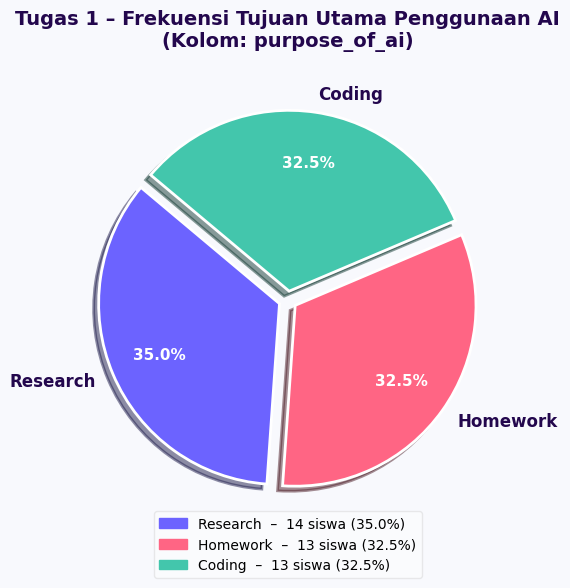


>> File 'grafik1_pie.png' berhasil disimpan.


In [ ]:
# ============================================================
#  TUGAS 1 – PIE CHART
#  Cari frekuensi kemunculan tujuan utama siswa dalam
#  memanfaatkan teknologi AI (purpose_of_ai)
#  Tampilkan dalam Pie Chart
#
#  Dataset  : dataset_kelasf.csv
#  Library  : pandas, matplotlib.pyplot
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ------------------------------------------------------------
# 1. LOAD DATASET DULU
# ------------------------------------------------------------
df = pd.read_csv('dataset_kelasf.csv')

print("=" * 50)
print("  PREVIEW DATASET")
print("=" * 50)
print(df.head())
print(f"\nShape    : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Kolom    : {df.columns.tolist()}")

# ------------------------------------------------------------
# 2. ANALISIS DATA – Hitung Frekuensi purpose_of_ai
# ------------------------------------------------------------
# dropna()      → abaikan baris kosong (NaN), karena siswa
#                 yang tidak pakai AI tidak memiliki purpose
# value_counts() → hitung berapa kali tiap kategori muncul,
#                  hasil diurutkan dari terbanyak ke tersedikit
purpose_counts = df['purpose_of_ai'].dropna().value_counts()

print("\n" + "=" * 50)
print("  HASIL ANALISIS FREKUENSI purpose_of_ai")
print("=" * 50)
print(purpose_counts.to_string())
print(f"\nTotal siswa yang menggunakan AI : {purpose_counts.sum()}")
print(f"Total siswa keseluruhan         : {len(df)}")
print(f"Siswa tidak menggunakan AI      : {len(df) - purpose_counts.sum()}")

# Hitung persentase masing-masing kategori
print("\nPersentase tiap kategori:")
for kategori, jumlah in purpose_counts.items():
    persen = jumlah / purpose_counts.sum() * 100
    print(f"  {kategori:10s} : {jumlah} siswa ({persen:.1f}%)")

# ------------------------------------------------------------
# 3. VISUALISASI – Pie Chart
# ------------------------------------------------------------
WARNA       = ['#6C63FF', '#FF6584', '#43C6AC']   # warna tiap irisan
BG_COLOR    = '#F8F9FD'                            # warna latar belakang
TITLE_COLOR = '#23074d'                            # warna teks judul

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG_COLOR)   # warna background figure
ax.set_facecolor(BG_COLOR)          # warna background axes

# --- Gambar Pie Chart ---
wedges, texts, autotexts = ax.pie(
    purpose_counts,               # data: jumlah tiap kategori
    labels=purpose_counts.index,  # label: nama kategori (Research, Homework, Coding)
    autopct='%1.1f%%',            # format persentase: 1 angka desimal
    colors=WARNA,                 # warna tiap irisan
    wedgeprops=dict(
        linewidth=2,              # ketebalan garis tepi irisan
        edgecolor='white'         # warna garis tepi (putih = pemisah antar irisan)
    ),
    startangle=140,
    pctdistance=0.72,
    explode=[0.05] * len(purpose_counts),
    shadow=True,                  # tambahkan efek bayangan di bawah pie
)

# --- Styling teks label ---
for text in texts:
    text.set_fontsize(12)
    text.set_color(TITLE_COLOR)
    text.set_fontweight('bold')

# --- Styling teks persentase (di dalam irisan) ---
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# --- Judul Grafik ---
ax.set_title(
    'Tugas 1 – Frekuensi Tujuan Utama Penggunaan AI\n(Kolom: purpose_of_ai)',
    fontsize=14,
    fontweight='bold',
    color=TITLE_COLOR,
    pad=20
)

# --- Legend dengan jumlah absolut ---
# Dibuat manual agar bisa menampilkan jumlah siswa di samping persentase
legend_labels = [
    f"{kategori}  –  {jumlah} siswa ({jumlah/purpose_counts.sum()*100:.1f}%)"
    for kategori, jumlah in purpose_counts.items()
]
patches = [
    mpatches.Patch(color=WARNA[i], label=legend_labels[i])
    for i in range(len(purpose_counts))
]
ax.legend(
    handles=patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.13),  # posisi legend di bawah pie
    ncol=1,
    fontsize=10,
    framealpha=0.4,
    edgecolor='#ccc'
)

plt.tight_layout()
plt.savefig('grafik1_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n>> File 'grafik1_pie.png' berhasil disimpan.")


  PREVIEW DATASET
   age education_level  study_hours_per_day uses_ai ai_tools_used  \
0   19         college                  1.4      No           NaN   
1   15          school                  3.9     Yes       Copilot   
2   15          school                  1.9     Yes       Copilot   
3   15          school                  2.8      No           NaN   
4   19         college                  2.7      No           NaN   

  purpose_of_ai  grades_before_ai  grades_after_ai  daily_screen_time_hours  
0           NaN                62               62                        3  
1      Research                56               61                        2  
2      Homework                75               88                        5  
3           NaN                55               55                        3  
4           NaN                59               59                        3  

Shape    : 100 baris x 9 kolom
Kolom    : ['age', 'education_level', 'study_hours_per_day', 'uses_

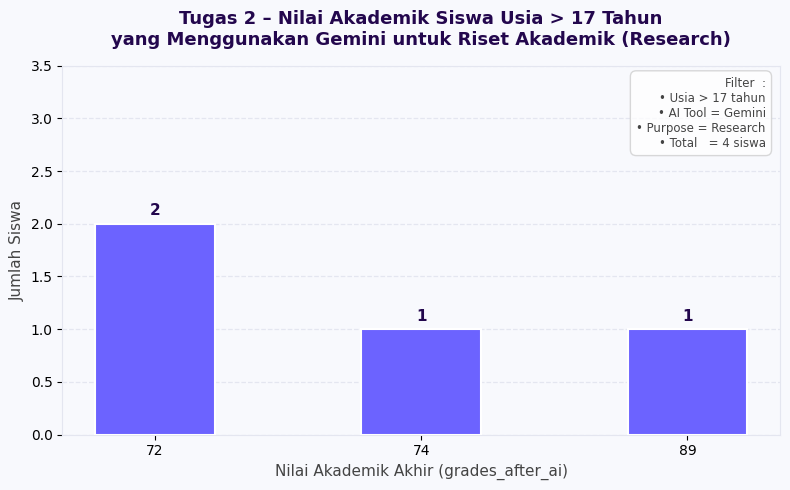


>> File 'grafik2_bar.png' berhasil disimpan.


In [ ]:
# ============================================================
#  TUGAS 2 – BAR CHART
#  Saring siswa berusia di atas 17 tahun yang menggunakan
#  alat AI bernama 'Gemini' untuk kebutuhan riset akademik
#  (Research). Tampilkan nilainya dalam Bar Chart.
#
#  Dataset  : dataset_kelasf.csv.csv
#  Library  : pandas, matplotlib.pyplot
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------
df = pd.read_csv('dataset_kelasf.csv')

print("=" * 55)
print("  PREVIEW DATASET")
print("=" * 55)
print(df.head())
print(f"\nShape    : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Kolom    : {df.columns.tolist()}")

# ------------------------------------------------------------
# 2. ANALISIS DATA – Filter / Saring Baris
# ------------------------------------------------------------

# Kondisi 1 : usia LEBIH DARI 17 tahun
mask_usia   = df['age'] > 17

# Kondisi 2 : alat AI yang digunakan adalah 'Gemini'
mask_gemini = df['ai_tools_used'] == 'Gemini'

# Kondisi 3 : tujuan penggunaan AI adalah 'Research'
mask_riset  = df['purpose_of_ai'] == 'Research'

# Gabungkan ketiga kondisi dengan operator & (AND)
# Hanya baris yang memenuhi SEMUA kondisi yang lolos filter
df_filtered = df[mask_usia & mask_gemini & mask_riset].copy()

print("\n" + "=" * 55)
print("  HASIL FILTER DATA")
print("=" * 55)
print(f"Jumlah siswa hasil filter : {len(df_filtered)} siswa")
print("\nDetail data siswa yang lolos filter:")
print(df_filtered[['age', 'ai_tools_used', 'purpose_of_ai',
                    'grades_before_ai', 'grades_after_ai']].to_string(index=False))

# ------------------------------------------------------------
# 3. AGREGASI – Hitung Frekuensi Nilai Akademik Akhir
# ------------------------------------------------------------
# value_counts() → hitung berapa siswa yang mendapat nilai
#                  yang sama pada grades_after_ai
# sort_index()   → urutkan berdasarkan nilai (kecil ke besar)
#                  agar sumbu X tampil rapi dari kiri ke kanan
g2_counts = df_filtered['grades_after_ai'].value_counts().sort_index()

print("\nFrekuensi grades_after_ai setelah filter:")
print(g2_counts.to_string())
print(f"\nNilai terendah  : {df_filtered['grades_after_ai'].min()}")
print(f"Nilai tertinggi : {df_filtered['grades_after_ai'].max()}")
print(f"Rata-rata nilai : {df_filtered['grades_after_ai'].mean():.2f}")

# ------------------------------------------------------------
# 4. VISUALISASI – Bar Chart
# ------------------------------------------------------------
WARNA_BAR   = '#6C63FF'    # warna batang utama
BG_COLOR    = '#F8F9FD'    # warna latar belakang
TITLE_COLOR = '#23074d'    # warna teks judul
GRID_COLOR  = '#E4E6F0'    # warna garis grid

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# --- Gambar Bar Chart ---
bars = ax.bar(
    g2_counts.index.astype(str),  # sumbu X : nilai akademik (diubah ke string)
    g2_counts.values,              # sumbu Y : jumlah siswa
    color=WARNA_BAR,
    width=0.45,                    # lebar tiap batang
    zorder=3,                      # batang tampil di depan grid
    edgecolor='white',             # garis tepi batang warna putih
    linewidth=1.5,
)

# --- Anotasi angka di atas setiap batang ---
# Memudahkan pembaca melihat nilai eksak tanpa menebak dari sumbu Y
for bar in bars:
    tinggi = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posisi X: tepat di tengah batang
        tinggi + 0.05,                       # posisi Y: sedikit di atas batang
        str(int(tinggi)),                    # teks: jumlah siswa (bilangan bulat)
        ha='center',                         # horizontal alignment: tengah
        va='bottom',                         # vertical alignment: bawah teks
        fontsize=11,
        color=TITLE_COLOR,
        fontweight='bold'
    )

# --- Judul dan Label Sumbu ---
ax.set_title(
    'Tugas 2 – Nilai Akademik Siswa Usia > 17 Tahun\n'
    'yang Menggunakan Gemini untuk Riset Akademik (Research)',
    fontsize=13,
    fontweight='bold',
    color=TITLE_COLOR,
    pad=15
)
ax.set_xlabel('Nilai Akademik Akhir (grades_after_ai)', fontsize=11, color='#444')
ax.set_ylabel('Jumlah Siswa', fontsize=11, color='#444')

# --- Batas sumbu Y (diberi ruang di atas untuk anotasi) ---
ax.set_ylim(0, g2_counts.max() + 1.5)

# --- Hanya tampilkan grid horizontal agar lebih bersih ---
ax.yaxis.grid(True, color=GRID_COLOR, linestyle='--', linewidth=0.9)
ax.xaxis.grid(False)           # grid vertikal dimatikan
ax.set_axisbelow(True)         # grid di belakang batang

# --- Styling garis tepi (spine) ---
for spine in ax.spines.values():
    spine.set_color(GRID_COLOR)

# --- Keterangan filter di dalam grafik ---
info_teks = (
    "Filter  :\n"
    "• Usia > 17 tahun\n"
    "• AI Tool = Gemini\n"
    "• Purpose = Research\n"
    f"• Total   = {len(df_filtered)} siswa"
)
ax.text(
    0.98, 0.97,          # posisi: pojok kanan atas (koordinat axes 0–1)
    info_teks,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=8.5,
    color='#444',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.75, edgecolor='#ccc')
)

plt.tight_layout()
plt.savefig('grafik2_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n>> File 'grafik2_bar.png' berhasil disimpan.")


  PREVIEW DATASET
   age education_level  study_hours_per_day uses_ai ai_tools_used  \
0   19         college                  1.4      No           NaN   
1   15          school                  3.9     Yes       Copilot   
2   15          school                  1.9     Yes       Copilot   
3   15          school                  2.8      No           NaN   
4   19         college                  2.7      No           NaN   

  purpose_of_ai  grades_before_ai  grades_after_ai  daily_screen_time_hours  
0           NaN                62               62                        3  
1      Research                56               61                        2  
2      Homework                75               88                        5  
3           NaN                55               55                        3  
4           NaN                59               59                        3  

Shape    : 100 baris x 9 kolom
Kolom    : ['age', 'education_level', 'study_hours_per_day', 'uses_

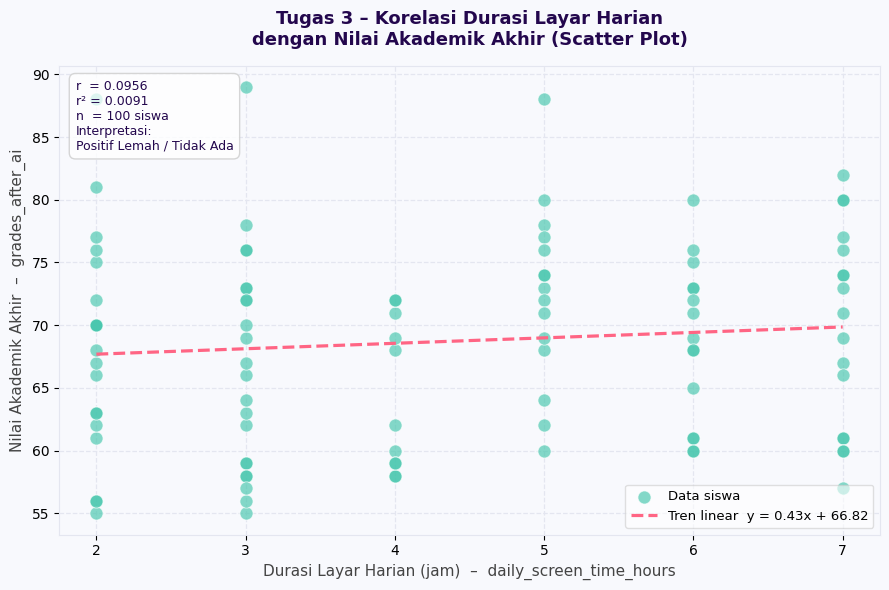


>> File 'grafik3_scatter.png' berhasil disimpan.


In [ ]:
# ============================================================
#  TUGAS 3 – SCATTER PLOT
#  Analisis korelasi hubungan antara durasi layar harian
#  (daily_screen_time_hours) dengan nilai akademik akhir
#  (grades_after_ai). Tampilkan dalam Scatter Plot.
#
#  Dataset  : dataset_kelasf.csv
#  Library  : pandas, matplotlib.pyplot, numpy
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------
df = pd.read_csv('dataset_kelasf.csv')

print("=" * 55)
print("  PREVIEW DATASET")
print("=" * 55)
print(df.head())
print(f"\nShape    : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Kolom    : {df.columns.tolist()}")

# ------------------------------------------------------------
# 2. SELEKSI KOLOM YANG RELEVAN
# ------------------------------------------------------------
# Ambil hanya 2 kolom yang dibutuhkan untuk analisis korelasi
# dropna() → buang baris yang salah satu kolomnya kosong (NaN)
df_g3 = df[['daily_screen_time_hours', 'grades_after_ai']].dropna()

print("\n" + "=" * 55)
print("  DATA YANG DIGUNAKAN (setelah dropna)")
print("=" * 55)
print(f"Jumlah baris valid : {len(df_g3)}")
print(f"\nStatistik deskriptif:")
print(df_g3.describe().round(2).to_string())

# ------------------------------------------------------------
# 3. ANALISIS KORELASI
# ------------------------------------------------------------

# --- Koefisien Korelasi Pearson (r) ---
# Mengukur kekuatan dan arah hubungan LINEAR antara dua variabel
# Rumus : r = Σ((x-x̄)(y-ȳ)) / √(Σ(x-x̄)² · Σ(y-ȳ)²)
# Rentang nilai r :
#   r =  1.0        → korelasi positif sempurna
#   r =  0.7 – 0.99 → positif kuat
#   r =  0.3 – 0.69 → positif sedang
#   r =  0.0 – 0.29 → positif lemah / tidak ada korelasi
#   r = -0.3 – -0.69→ negatif sedang
#   r = -1.0        → korelasi negatif sempurna
corr = df_g3['daily_screen_time_hours'].corr(df_g3['grades_after_ai'])

# Tentukan interpretasi otomatis
if corr >= 0.7:
    kekuatan = "Positif Kuat"
elif corr >= 0.3:
    kekuatan = "Positif Sedang"
elif corr >= 0.0:
    kekuatan = "Positif Lemah / Tidak Ada"
elif corr >= -0.3:
    kekuatan = "Negatif Lemah / Tidak Ada"
elif corr >= -0.7:
    kekuatan = "Negatif Sedang"
else:
    kekuatan = "Negatif Kuat"

print("\n" + "=" * 55)
print("  HASIL ANALISIS KORELASI")
print("=" * 55)
print(f"Koefisien Korelasi Pearson (r) : {corr:.4f}")
print(f"Koefisien Determinasi (r²)     : {corr**2:.4f}")
print(f"Interpretasi                   : {kekuatan}")
print(f"\nKesimpulan:")
print(f"  Hubungan antara durasi layar harian dan nilai akademik")
print(f"  akhir bersifat '{kekuatan}' (r = {corr:.4f}).")
print(f"  Artinya durasi layar hanya menjelaskan {corr**2*100:.2f}%")
print(f"  variasi pada nilai akademik (r² = {corr**2:.4f}).")

# --- Garis Tren Regresi Linear ---
# np.polyfit(x, y, derajat) → cari koefisien a dan b dari y = ax + b
# derajat=1 berarti regresi linier (garis lurus)
# Mengembalikan array [a, b] → a=kemiringan, b=titik potong Y
koef = np.polyfit(df_g3['daily_screen_time_hours'],
                  df_g3['grades_after_ai'], 1)
a, b = koef[0], koef[1]  # a = slope, b = intercept

# np.poly1d() → membuat fungsi dari koefisien agar bisa dipanggil
# seperti fungsi biasa: p(x) menghasilkan nilai y pada titik x
p = np.poly1d(koef)

# Buat 200 titik X yang merata dari min ke max untuk garis halus
x_line = np.linspace(
    df_g3['daily_screen_time_hours'].min(),
    df_g3['daily_screen_time_hours'].max(),
    200
)

print(f"\nPersamaan Regresi Linear:")
print(f"  y = {a:.4f}x + {b:.4f}")
print(f"  → Setiap tambah 1 jam layar, nilai berubah {a:+.4f} poin")

# ------------------------------------------------------------
# 4. VISUALISASI – Scatter Plot
# ------------------------------------------------------------
WARNA_TITIK = '#43C6AC'    # warna titik data
WARNA_TREN  = '#FF6584'    # warna garis tren
BG_COLOR    = '#F8F9FD'    # latar belakang
TITLE_COLOR = '#23074d'    # warna judul
GRID_COLOR  = '#E4E6F0'    # warna grid

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# --- Gambar Titik-titik Data (Scatter) ---
ax.scatter(
    df_g3['daily_screen_time_hours'],  # sumbu X: durasi layar (jam)
    df_g3['grades_after_ai'],          # sumbu Y: nilai akademik akhir
    color=WARNA_TITIK,
    alpha=0.65,          # transparansi 65% agar titik yang overlap terlihat
    edgecolors='white',  # tepi putih pada tiap titik
    linewidth=0.8,
    s=90,                # ukuran titik (dalam satuan points²)
    zorder=3,            # titik tampil di depan grid
    label='Data siswa'
)

# --- Gambar Garis Tren Regresi Linear ---
ax.plot(
    x_line,        # nilai X yang sudah disiapkan
    p(x_line),     # nilai Y dari fungsi regresi p(x)
    color=WARNA_TREN,
    linewidth=2.3,
    linestyle='--',
    zorder=4,
    label=f'Tren linear  y = {a:.2f}x + {b:.2f}'
)

# --- Kotak Informasi Korelasi ---
info_korelasi = (
    f"r  = {corr:.4f}\n"
    f"r² = {corr**2:.4f}\n"
    f"n  = {len(df_g3)} siswa\n"
    f"Interpretasi:\n{kekuatan}"
)
ax.text(
    0.02, 0.97,           # pojok kiri atas area grafik
    info_korelasi,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=9,
    color=TITLE_COLOR,
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.80,
        edgecolor='#ccc'
    )
)

# --- Legend ---
ax.legend(fontsize=9.5, loc='lower right', framealpha=0.6)

# --- Judul dan Label Sumbu ---
ax.set_title(
    'Tugas 3 – Korelasi Durasi Layar Harian\n'
    'dengan Nilai Akademik Akhir (Scatter Plot)',
    fontsize=13,
    fontweight='bold',
    color=TITLE_COLOR,
    pad=15
)
ax.set_xlabel(
    'Durasi Layar Harian (jam)  –  daily_screen_time_hours',
    fontsize=11, color='#444'
)
ax.set_ylabel(
    'Nilai Akademik Akhir  –  grades_after_ai',
    fontsize=11, color='#444'
)

# --- Grid kedua sumbu agar mudah membaca posisi titik ---
ax.yaxis.grid(True, color=GRID_COLOR, linestyle='--', linewidth=0.9)
ax.xaxis.grid(True, color=GRID_COLOR, linestyle='--', linewidth=0.9)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color(GRID_COLOR)

plt.tight_layout()
plt.savefig('grafik3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n>> File 'grafik3_scatter.png' berhasil disimpan.")


  PREVIEW DATASET
   age education_level  study_hours_per_day uses_ai ai_tools_used  \
0   19         college                  1.4      No           NaN   
1   15          school                  3.9     Yes       Copilot   
2   15          school                  1.9     Yes       Copilot   
3   15          school                  2.8      No           NaN   
4   19         college                  2.7      No           NaN   

  purpose_of_ai  grades_before_ai  grades_after_ai  daily_screen_time_hours  
0           NaN                62               62                        3  
1      Research                56               61                        2  
2      Homework                75               88                        5  
3           NaN                55               55                        3  
4           NaN                59               59                        3  

Shape    : 100 baris x 9 kolom
Kolom    : ['age', 'education_level', 'study_hours_per_day', 'uses_

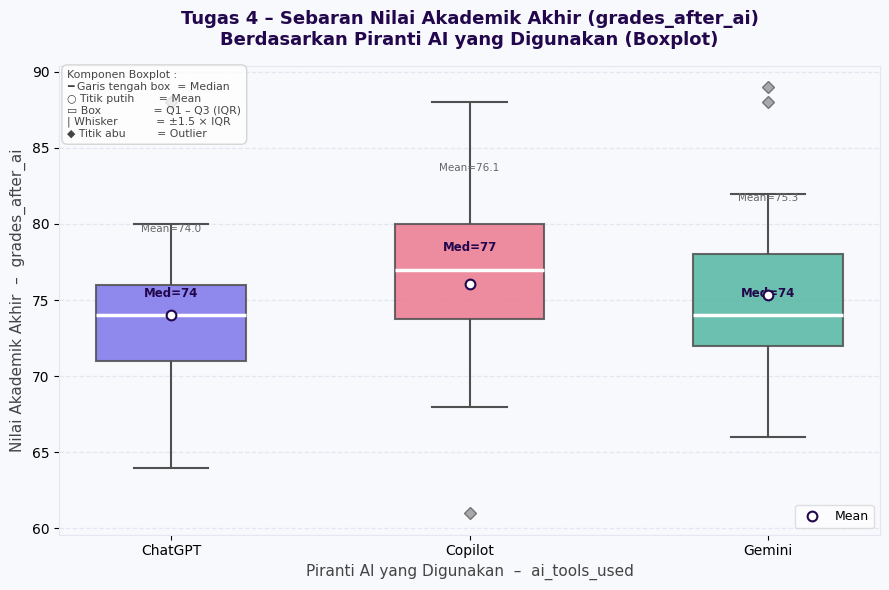


>> File 'grafik4_boxplot.png' berhasil disimpan.


In [ ]:
# ============================================================
#  TUGAS 4 – BOXPLOT
#  Tampilkan sebaran peningkatan nilai akademik (grades_after_ai)
#  berdasarkan piranti AI yang digunakan menggunakan Boxplot.
#
#  Dataset  : dataset_kelasf.csv
#  Library  : pandas, matplotlib.pyplot, seaborn
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------
df = pd.read_csv('dataset_kelasf.csv')

print("=" * 55)
print("  PREVIEW DATASET")
print("=" * 55)
print(df.head())
print(f"\nShape    : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Kolom    : {df.columns.tolist()}")

# ------------------------------------------------------------
# 2. SELEKSI KOLOM YANG RELEVAN
# ------------------------------------------------------------
# Ambil hanya 2 kolom: piranti AI dan nilai akademik akhir
# dropna() → buang baris yang tidak punya piranti AI (siswa
#             yang tidak menggunakan AI tidak punya ai_tools_used)
df_g4 = df[['ai_tools_used', 'grades_after_ai']].dropna()

print("\n" + "=" * 55)
print("  DATA YANG DIGUNAKAN (setelah dropna)")
print("=" * 55)
print(f"Jumlah baris valid  : {len(df_g4)}")
print(f"Piranti AI unik     : {sorted(df_g4['ai_tools_used'].unique())}")

# ------------------------------------------------------------
# 3. ANALISIS STATISTIK DESKRIPTIF PER PIRANTI AI
# ------------------------------------------------------------
# groupby() → kelompokkan baris berdasarkan kategori ai_tools_used
# describe() → hitung statistik lengkap: count, mean, std,
#              min, Q1(25%), median(50%), Q3(75%), max
stats = (df_g4
         .groupby('ai_tools_used')['grades_after_ai']
         .describe()
         .round(2))

print("\n" + "=" * 55)
print("  STATISTIK DESKRIPTIF grades_after_ai PER PIRANTI AI")
print("=" * 55)
print(stats.to_string())

# Tampilkan juga IQR (Interquartile Range) = Q3 - Q1
# IQR mengukur sebaran 50% data tengah (tidak terpengaruh outlier)
print("\nInterquartile Range (IQR = Q3 - Q1):")
for tool in sorted(df_g4['ai_tools_used'].unique()):
    sub    = df_g4[df_g4['ai_tools_used'] == tool]['grades_after_ai']
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    iqr    = q3 - q1
    print(f"  {tool:10s} → Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")

# Deteksi outlier menggunakan aturan 1.5 × IQR
# Outlier bawah : nilai < Q1 - 1.5×IQR
# Outlier atas  : nilai > Q3 + 1.5×IQR
print("\nDeteksi Outlier (metode 1.5 × IQR):")
for tool in sorted(df_g4['ai_tools_used'].unique()):
    sub    = df_g4[df_g4['ai_tools_used'] == tool]['grades_after_ai']
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    iqr    = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas  = q3 + 1.5 * iqr
    outliers = sub[(sub < batas_bawah) | (sub > batas_atas)]
    if len(outliers) > 0:
        print(f"  {tool:10s} → {len(outliers)} outlier: {outliers.values.tolist()}")
    else:
        print(f"  {tool:10s} → Tidak ada outlier")

# ------------------------------------------------------------
# 4. VISUALISASI – Boxplot
# ------------------------------------------------------------
WARNA_BOX   = {'ChatGPT': '#6C63FF', 'Copilot': '#FF6584', 'Gemini': '#43C6AC'}
BG_COLOR    = '#F8F9FD'
TITLE_COLOR = '#23074d'
GRID_COLOR  = '#E4E6F0'

tools_sorted = sorted(df_g4['ai_tools_used'].unique())  # urutan alfabet

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# --- Gambar Boxplot menggunakan seaborn ---
# Seaborn otomatis menghitung dan menggambar:
#   ┌─────────────────────────────────────────────────┐
#   │  Garis atas whisker  → Q3 + 1.5×IQR (atau max) │
#   │  Tepi atas box       → Q3 (persentil ke-75)     │
#   │  Garis tengah box    → Median (persentil ke-50)  │
#   │  Tepi bawah box      → Q1 (persentil ke-25)     │
#   │  Garis bawah whisker → Q1 - 1.5×IQR (atau min) │
#   │  Titik di luar       → Outlier                   │
#   └─────────────────────────────────────────────────┘
sns.boxplot(
    data=df_g4,
    x='ai_tools_used',        # sumbu X: kategori piranti AI
    y='grades_after_ai',      # sumbu Y: nilai akademik akhir
    hue='ai_tools_used',      # warna berbeda tiap kategori
    palette=WARNA_BOX,        # peta warna per kategori
    order=tools_sorted,       # urutan kategori di sumbu X
    width=0.5,                # lebar box
    linewidth=1.5,            # ketebalan garis box
    flierprops=dict(          # styling titik outlier
        marker='D',           # bentuk berlian (diamond)
        markerfacecolor='#888',
        markersize=6,
        alpha=0.7,
        linestyle='none'
    ),
    medianprops=dict(         # styling garis median
        color='white',
        linewidth=2.5
    ),
    boxprops=dict(alpha=0.85),  # transparansi box
    legend=False,
    ax=ax,
)

# --- Anotasi Statistik di atas setiap box ---
# Tampilkan median dan mean agar mudah dibandingkan
for i, tool in enumerate(tools_sorted):
    sub    = df_g4[df_g4['ai_tools_used'] == tool]['grades_after_ai']
    median = sub.median()
    mean   = sub.mean()
    q3     = sub.quantile(0.75)

    # Teks median (putih tebal di dalam garis median)
    ax.text(i, median + 1.2, f'Med={median:.0f}',
            ha='center', fontsize=8.5,
            color=TITLE_COLOR, fontweight='bold')

    # Teks mean (kecil di atas box, berwarna abu)
    ax.text(i, q3 + 3.5, f'Mean={mean:.1f}',
            ha='center', fontsize=7.5, color='#666')

# --- Tambahkan titik Mean sebagai marker ─── ---
for i, tool in enumerate(tools_sorted):
    mean_val = df_g4[df_g4['ai_tools_used'] == tool]['grades_after_ai'].mean()
    ax.plot(i, mean_val,
            marker='o', color='white', markersize=7,
            markeredgecolor=TITLE_COLOR, markeredgewidth=1.5,
            zorder=5, label='Mean' if i == 0 else '')

ax.legend(fontsize=9, loc='lower right', framealpha=0.6)

# --- Judul dan Label Sumbu ---
ax.set_title(
    'Tugas 4 – Sebaran Nilai Akademik Akhir (grades_after_ai)\n'
    'Berdasarkan Piranti AI yang Digunakan (Boxplot)',
    fontsize=13,
    fontweight='bold',
    color=TITLE_COLOR,
    pad=15
)
ax.set_xlabel('Piranti AI yang Digunakan  –  ai_tools_used',
              fontsize=11, color='#444')
ax.set_ylabel('Nilai Akademik Akhir  –  grades_after_ai',
              fontsize=11, color='#444')

# --- Grid hanya horizontal ---
ax.yaxis.grid(True, color=GRID_COLOR, linestyle='--', linewidth=0.9)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color(GRID_COLOR)

# --- Keterangan komponen Boxplot (pojok kiri atas) ---
keterangan = (
    "Komponen Boxplot :\n"
    "━ Garis tengah box  = Median\n"
    "○ Titik putih       = Mean\n"
    "▭ Box               = Q1 – Q3 (IQR)\n"
    "| Whisker           = ±1.5 × IQR\n"
    "◆ Titik abu         = Outlier"
)
ax.text(
    0.01, 0.99,
    keterangan,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=7.8,
    color='#444',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.80,
        edgecolor='#ccc'
    )
)

plt.tight_layout()
plt.savefig('grafik4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n>> File 'grafik4_boxplot.png' berhasil disimpan.")


  LOAD DATASET
Shape    : 100 baris x 9 kolom
Kolom    : ['age', 'education_level', 'study_hours_per_day', 'uses_ai', 'ai_tools_used', 'purpose_of_ai', 'grades_before_ai', 'grades_after_ai', 'daily_screen_time_hours']

Data berhasil disiapkan untuk 4 grafik.
  G1 purpose_counts : {'Research': 14, 'Homework': 13, 'Coding': 13}
  G2 filtered rows  : 4 siswa
  G3 valid rows     : 100 | r = 0.0956
  G4 piranti AI     : ['ChatGPT', 'Copilot', 'Gemini']



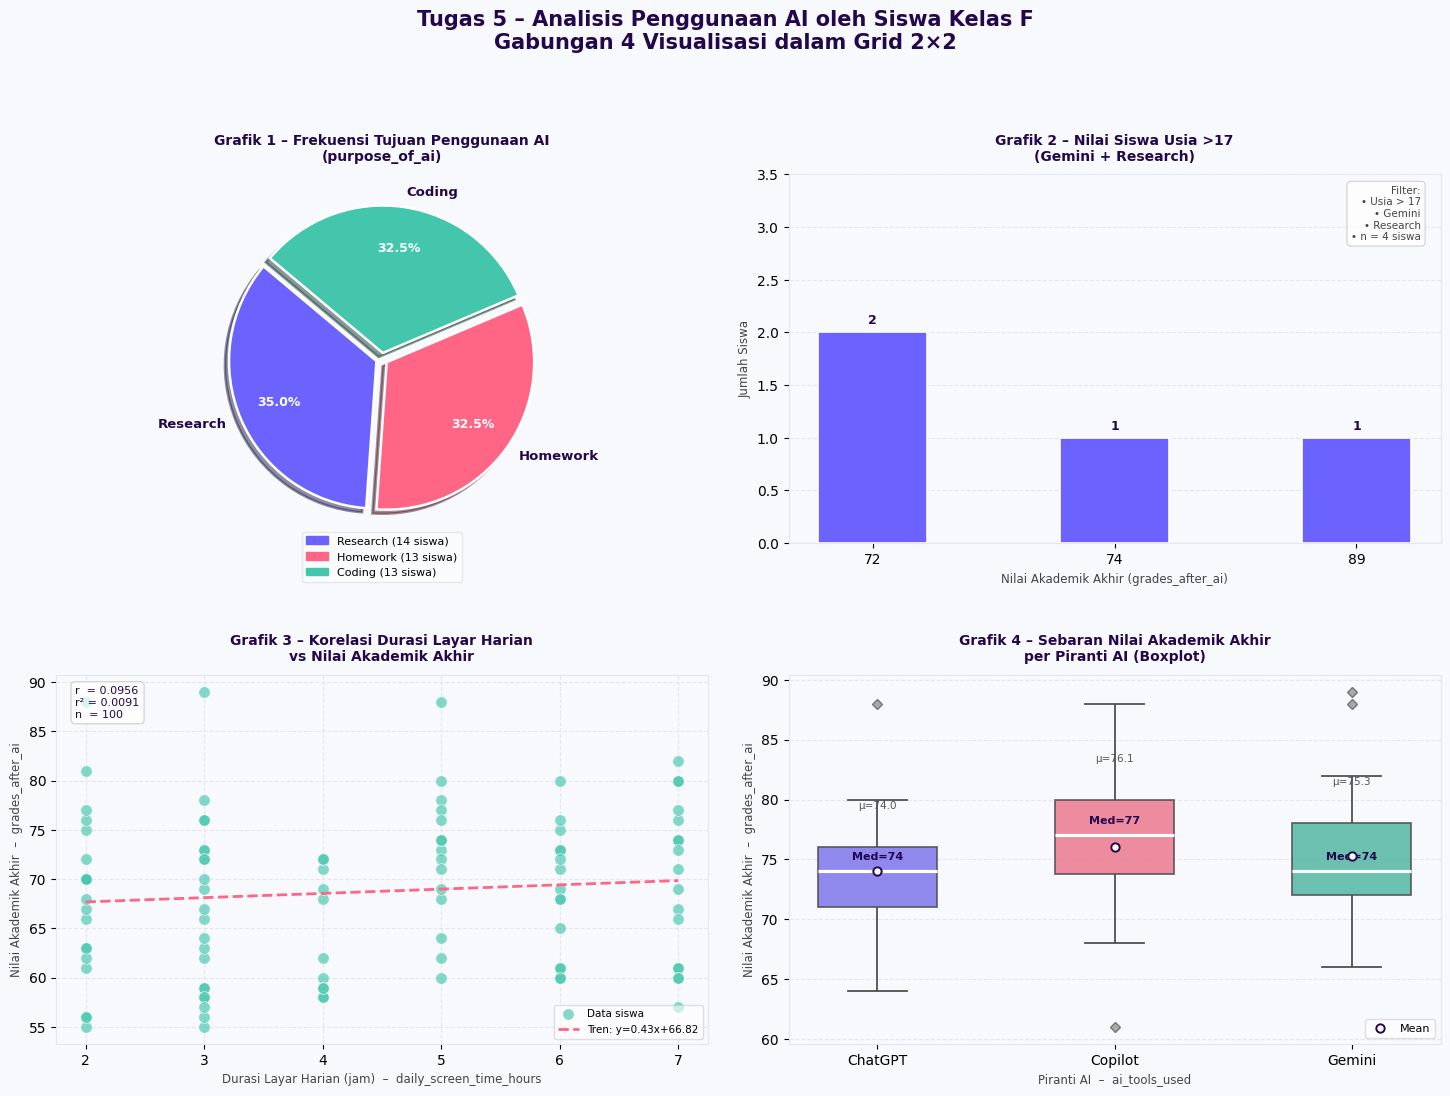

  SELESAI
>> File 'grafik5_combined.png' berhasil disimpan.

Susunan Grid 2×2 :
  axes[0,0] → Grafik 1 Pie Chart
  axes[0,1] → Grafik 2 Bar Chart
  axes[1,0] → Grafik 3 Scatter Plot
  axes[1,1] → Grafik 4 Boxplot


In [ ]:
# ============================================================
#  TUGAS 5 – GRAFIK GABUNGAN GRID 2×2
#  Menggabungkan Grafik 1, 2, 3, dan 4 ke dalam satu layout
#  menggunakan plt.subplots(2, 2) dengan pendekatan objek
#  ax = axes[baris, kolom]
#
#  Susunan Grid :
#   [0,0] Pie Chart    │ [0,1] Bar Chart
#   ───────────────────┼──────────────────
#   [1,0] Scatter Plot │ [1,1] Boxplot
#
#  Dataset  : dataset_kelasf.csv
#  Library  : pandas, matplotlib.pyplot, seaborn, numpy
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ============================================================
# 1. LOAD DATASET
# ============================================================
df = pd.read_csv('dataset_kelasf.csv')

print("=" * 55)
print("  LOAD DATASET")
print("=" * 55)
print(f"Shape    : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Kolom    : {df.columns.tolist()}\n")

# ============================================================
# 2. SIAPKAN SEMUA DATA (satu kali, dipakai oleh 4 grafik)
# ============================================================

# --- Data Grafik 1 – Pie Chart ---
# Frekuensi purpose_of_ai, buang NaN
purpose_counts = df['purpose_of_ai'].dropna().value_counts()

# --- Data Grafik 2 – Bar Chart ---
# Filter: usia > 17, Gemini, Research
df_g2     = df[(df['age'] > 17) &
               (df['ai_tools_used'] == 'Gemini') &
               (df['purpose_of_ai'] == 'Research')].copy()
g2_counts = df_g2['grades_after_ai'].value_counts().sort_index()

# --- Data Grafik 3 – Scatter Plot ---
# Kolom durasi layar & nilai akhir, tanpa NaN
df_g3 = df[['daily_screen_time_hours', 'grades_after_ai']].dropna()

# Hitung korelasi Pearson
corr = df_g3['daily_screen_time_hours'].corr(df_g3['grades_after_ai'])

# Hitung garis tren regresi linear
koef   = np.polyfit(df_g3['daily_screen_time_hours'],
                    df_g3['grades_after_ai'], 1)
p      = np.poly1d(koef)
x_line = np.linspace(df_g3['daily_screen_time_hours'].min(),
                     df_g3['daily_screen_time_hours'].max(), 200)

# --- Data Grafik 4 – Boxplot ---
# Kolom piranti AI & nilai akhir, tanpa NaN
df_g4        = df[['ai_tools_used', 'grades_after_ai']].dropna()
tools_sorted = sorted(df_g4['ai_tools_used'].unique())

print("Data berhasil disiapkan untuk 4 grafik.")
print(f"  G1 purpose_counts : {purpose_counts.to_dict()}")
print(f"  G2 filtered rows  : {len(df_g2)} siswa")
print(f"  G3 valid rows     : {len(df_g3)} | r = {corr:.4f}")
print(f"  G4 piranti AI     : {tools_sorted}\n")

# ============================================================
# 3. DEFINISI WARNA & STYLE (konsisten di semua grafik)
# ============================================================
WARNA_PIE   = ['#6C63FF', '#FF6584', '#43C6AC']
WARNA_BAR   = '#6C63FF'
WARNA_TITIK = '#43C6AC'
WARNA_TREN  = '#FF6584'
WARNA_BOX   = {'ChatGPT': '#6C63FF', 'Copilot': '#FF6584', 'Gemini': '#43C6AC'}
BG_COLOR    = '#F8F9FD'
TITLE_COLOR = '#23074d'
GRID_COLOR  = '#E4E6F0'

# ============================================================
# 4. BUAT FIGURE DAN GRID 2×2
# ============================================================
# plt.subplots(nrows, ncols, figsize=(lebar, tinggi))
# Mengembalikan :
#   fig    → objek Figure (kanvas utama)
#   axes   → array 2D berisi 4 objek Axes (subplot)
#             axes[0,0], axes[0,1], axes[1,0], axes[1,1]
fig, axes = plt.subplots(
    2, 2,                  # 2 baris, 2 kolom → 4 panel
    figsize=(15, 11)       # lebar=15 inch, tinggi=11 inch
)
fig.patch.set_facecolor(BG_COLOR)

# Judul utama untuk seluruh figure (di atas semua panel)
fig.suptitle(
    'Tugas 5 – Analisis Penggunaan AI oleh Siswa Kelas F\n'
    'Gabungan 4 Visualisasi dalam Grid 2×2',
    fontsize=15,
    fontweight='bold',
    color=TITLE_COLOR,
    y=1.01               # posisi vertikal sedikit di atas figure
)

# ============================================================
# 5A. PANEL [0,0] – Pie Chart (Grafik 1)
#     Frekuensi tujuan penggunaan AI (purpose_of_ai)
# ============================================================
ax_pie = axes[0, 0]   # akses panel baris-0, kolom-0
ax_pie.set_facecolor(BG_COLOR)

wedges, texts, autotexts = ax_pie.pie(
    purpose_counts,
    labels=purpose_counts.index,
    autopct='%1.1f%%',
    colors=WARNA_PIE,
    wedgeprops=dict(linewidth=1.8, edgecolor='white'),
    startangle=140,
    pctdistance=0.72,
    explode=[0.04] * len(purpose_counts),
    shadow=True,
)
for t  in texts:      t.set_fontsize(9.5); t.set_color(TITLE_COLOR); t.set_fontweight('bold')
for at in autotexts:  at.set_fontsize(9);  at.set_color('white');     at.set_fontweight('bold')

# Legend kecil di bawah pie
legend_labels = [f"{k} ({v} siswa)" for k, v in purpose_counts.items()]
patches = [mpatches.Patch(color=WARNA_PIE[i], label=legend_labels[i])
           for i in range(len(purpose_counts))]
ax_pie.legend(handles=patches, loc='lower center',
              bbox_to_anchor=(0.5, -0.12), ncol=1,
              fontsize=8, framealpha=0.4)

ax_pie.set_title('Grafik 1 – Frekuensi Tujuan Penggunaan AI\n(purpose_of_ai)',
                 fontsize=10, fontweight='bold', color=TITLE_COLOR, pad=10)

# ============================================================
# 5B. PANEL [0,1] – Bar Chart (Grafik 2)
#     Nilai siswa usia >17, Gemini, Research
# ============================================================
ax_bar = axes[0, 1]   # akses panel baris-0, kolom-1
ax_bar.set_facecolor(BG_COLOR)

bars = ax_bar.bar(
    g2_counts.index.astype(str),
    g2_counts.values,
    color=WARNA_BAR,
    width=0.45,
    zorder=3,
    edgecolor='white',
    linewidth=1.2,
)
# Anotasi angka di atas setiap batang
for bar in bars:
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                str(int(h)), ha='center', va='bottom',
                fontsize=9, color=TITLE_COLOR, fontweight='bold')

ax_bar.set_title('Grafik 2 – Nilai Siswa Usia >17\n(Gemini + Research)',
                 fontsize=10, fontweight='bold', color=TITLE_COLOR, pad=10)
ax_bar.set_xlabel('Nilai Akademik Akhir (grades_after_ai)', fontsize=8.5, color='#444')
ax_bar.set_ylabel('Jumlah Siswa', fontsize=8.5, color='#444')
ax_bar.set_ylim(0, g2_counts.max() + 1.5)
ax_bar.yaxis.grid(True, color=GRID_COLOR, linestyle='--', linewidth=0.8)
ax_bar.set_axisbelow(True)
for sp in ax_bar.spines.values(): sp.set_color(GRID_COLOR)

# Info filter di pojok kanan atas
ax_bar.text(0.97, 0.97,
            f"Filter:\n• Usia > 17\n• Gemini\n• Research\n• n = {len(df_g2)} siswa",
            transform=ax_bar.transAxes, ha='right', va='top',
            fontsize=7.5, color='#444',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      alpha=0.75, edgecolor='#ccc'))

# ============================================================
# 5C. PANEL [1,0] – Scatter Plot (Grafik 3)
#     Korelasi durasi layar vs nilai akademik akhir
# ============================================================
ax_scat = axes[1, 0]   # akses panel baris-1, kolom-0
ax_scat.set_facecolor(BG_COLOR)

ax_scat.scatter(
    df_g3['daily_screen_time_hours'],
    df_g3['grades_after_ai'],
    color=WARNA_TITIK,
    alpha=0.65,
    edgecolors='white',
    linewidth=0.7,
    s=70,
    zorder=3,
    label='Data siswa'
)
# Garis tren regresi linear
ax_scat.plot(x_line, p(x_line),
             color=WARNA_TREN, linewidth=2.0,
             linestyle='--', zorder=4,
             label=f'Tren: y={koef[0]:.2f}x+{koef[1]:.2f}')

# Kotak nilai korelasi
ax_scat.text(0.03, 0.97, f"r  = {corr:.4f}\nr² = {corr**2:.4f}\nn  = {len(df_g3)}",
             transform=ax_scat.transAxes, ha='left', va='top',
             fontsize=8, color=TITLE_COLOR,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       alpha=0.78, edgecolor='#ccc'))

ax_scat.legend(fontsize=7.5, loc='lower right', framealpha=0.6)
ax_scat.set_title('Grafik 3 – Korelasi Durasi Layar Harian\nvs Nilai Akademik Akhir',
                  fontsize=10, fontweight='bold', color=TITLE_COLOR, pad=10)
ax_scat.set_xlabel('Durasi Layar Harian (jam)  –  daily_screen_time_hours',
                   fontsize=8.5, color='#444')
ax_scat.set_ylabel('Nilai Akademik Akhir  –  grades_after_ai',
                   fontsize=8.5, color='#444')
ax_scat.yaxis.grid(True, color=GRID_COLOR, linestyle='--', linewidth=0.8)
ax_scat.xaxis.grid(True, color=GRID_COLOR, linestyle='--', linewidth=0.8)
ax_scat.set_axisbelow(True)
for sp in ax_scat.spines.values(): sp.set_color(GRID_COLOR)

# ============================================================
# 5D. PANEL [1,1] – Boxplot (Grafik 4)
#     Sebaran nilai per piranti AI
# ============================================================
ax_box = axes[1, 1]   # akses panel baris-1, kolom-1
ax_box.set_facecolor(BG_COLOR)

sns.boxplot(
    data=df_g4,
    x='ai_tools_used',
    y='grades_after_ai',
    hue='ai_tools_used',
    palette=WARNA_BOX,
    order=tools_sorted,
    width=0.5,
    linewidth=1.3,
    flierprops=dict(marker='D', markerfacecolor='#888',
                    markersize=5, alpha=0.7, linestyle='none'),
    medianprops=dict(color='white', linewidth=2.3),
    boxprops=dict(alpha=0.85),
    legend=False,
    ax=ax_box,
)
# Anotasi median & titik mean di setiap box
for i, tool in enumerate(tools_sorted):
    sub      = df_g4[df_g4['ai_tools_used'] == tool]['grades_after_ai']
    median   = sub.median()
    mean_val = sub.mean()
    q3       = sub.quantile(0.75)
    ax_box.text(i, median + 1.0, f'Med={median:.0f}',
                ha='center', fontsize=8, color=TITLE_COLOR, fontweight='bold')
    ax_box.text(i, q3 + 3.2, f'μ={mean_val:.1f}',
                ha='center', fontsize=7.5, color='#555')
    ax_box.plot(i, mean_val, marker='o', color='white',
                markersize=6, markeredgecolor=TITLE_COLOR,
                markeredgewidth=1.4, zorder=5,
                label='Mean' if i == 0 else '')

ax_box.legend(fontsize=8, loc='lower right', framealpha=0.6)
ax_box.set_title('Grafik 4 – Sebaran Nilai Akademik Akhir\nper Piranti AI (Boxplot)',
                 fontsize=10, fontweight='bold', color=TITLE_COLOR, pad=10)
ax_box.set_xlabel('Piranti AI  –  ai_tools_used', fontsize=8.5, color='#444')
ax_box.set_ylabel('Nilai Akademik Akhir  –  grades_after_ai', fontsize=8.5, color='#444')
ax_box.yaxis.grid(True, color=GRID_COLOR, linestyle='--', linewidth=0.8)
ax_box.set_axisbelow(True)
for sp in ax_box.spines.values(): sp.set_color(GRID_COLOR)

# ============================================================
# 6. RAPIKAN LAYOUT DAN SIMPAN
# ============================================================
# tight_layout() → sesuaikan spasi antar panel secara otomatis
# pad  → jarak antara tepi figure dan panel terluar
# h_pad → jarak vertikal antar baris panel
# w_pad → jarak horizontal antar kolom panel
plt.tight_layout(pad=2.5, h_pad=3.5, w_pad=2.5)

plt.savefig('grafik5_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 55)
print("  SELESAI")
print("=" * 55)
print(">> File 'grafik5_combined.png' berhasil disimpan.")
print("\nSusunan Grid 2×2 :")
print("  axes[0,0] → Grafik 1 Pie Chart")
print("  axes[0,1] → Grafik 2 Bar Chart")
print("  axes[1,0] → Grafik 3 Scatter Plot")
print("  axes[1,1] → Grafik 4 Boxplot")
